In [1]:
!pip install statsmodels


In [2]:
# STEP 2: Import basic libraries

import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose


In [3]:
import kagglehub

# Download latest version of the dataset
path = kagglehub.dataset_download("amirmotefaker/uber-dataset-from-april-to-september-2014")

print("Path to dataset files:", path)


100%|██████████| 27.6M/27.6M [00:00<00:00, 105MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/amirmotefaker/uber-dataset-from-april-to-september-2014/versions/1


In [4]:
# STEP 3: Load CSV files from kagglehub dataset folder

import os
import pandas as pd

folder = path   # path returned by kagglehub

csv_files = []

# find all csv files inside the folder
for root, dirs, files in os.walk(folder):
    for file in files:
        if file.endswith(".csv"):
            csv_files.append(os.path.join(root, file))

print("CSV files found:", len(csv_files))
for f in csv_files:
    print(" -", f)

# load them
dfs = [pd.read_csv(f) for f in csv_files]

# combine into single dataframe
uber_df = pd.concat(dfs, ignore_index=True)

print("Combined shape:", uber_df.shape)
uber_df.head()


CSV files found: 6
 - /root/.cache/kagglehub/datasets/amirmotefaker/uber-dataset-from-april-to-september-2014/versions/1/Uber-dataset/uber-raw-data-apr14.csv/uber-raw-data-apr14.csv
 - /root/.cache/kagglehub/datasets/amirmotefaker/uber-dataset-from-april-to-september-2014/versions/1/Uber-dataset/uber-raw-data-jun14.csv/uber-raw-data-jun14.csv
 - /root/.cache/kagglehub/datasets/amirmotefaker/uber-dataset-from-april-to-september-2014/versions/1/Uber-dataset/uber-raw-data-jul14.csv/uber-raw-data-jul14.csv
 - /root/.cache/kagglehub/datasets/amirmotefaker/uber-dataset-from-april-to-september-2014/versions/1/Uber-dataset/uber-raw-data-may14.csv/uber-raw-data-may14.csv
 - /root/.cache/kagglehub/datasets/amirmotefaker/uber-dataset-from-april-to-september-2014/versions/1/Uber-dataset/uber-raw-data-aug14.csv/uber-raw-data-aug14.csv
 - /root/.cache/kagglehub/datasets/amirmotefaker/uber-dataset-from-april-to-september-2014/versions/1/Uber-dataset/uber-raw-data-sep14.csv/uber-raw-data-sep14.csv
Com

,Date/Time,Lat,Lon,Base
0,4/1/2014 0:11:00,40.7690,-73.9549,B02512
1,4/1/2014 0:17:00,40.7267,-74.0345,B02512
2,4/1/2014 0:21:00,40.7316,-73.9873,B02512
3,4/1/2014 0:28:00,40.7588,-73.9776,B02512
4,4/1/2014 0:33:00,40.7594,-73.9722,B02512


In [5]:
# STEP 4: Basic Data Cleaning

# check missing values
print("Missing values per column:")
print(uber_df.isnull().sum())

# drop rows with missing data (if any)
uber_df = uber_df.dropna()

# drop duplicate rows
uber_df = uber_df.drop_duplicates()

print("\nShape after cleaning:", uber_df.shape)

# show sample
uber_df.head()


Missing values per column:
Date/Time    0
Lat          0
Lon          0
Base         0
dtype: int64

Shape after cleaning: (4451746, 4)


,Date/Time,Lat,Lon,Base
0,4/1/2014 0:11:00,40.7690,-73.9549,B02512
1,4/1/2014 0:17:00,40.7267,-74.0345,B02512
2,4/1/2014 0:21:00,40.7316,-73.9873,B02512
3,4/1/2014 0:28:00,40.7588,-73.9776,B02512
4,4/1/2014 0:33:00,40.7594,-73.9722,B02512


In [6]:
# STEP 5: Convert Date/Time to datetime and sort

uber_df["Date/Time"] = pd.to_datetime(uber_df["Date/Time"], errors='coerce')

uber_df = uber_df.sort_values("Date/Time")

uber_df = uber_df.set_index("Date/Time")

print(uber_df.head())
print("\nData index type:", type(uber_df.index))


                         Lat      Lon    Base
Date/Time                                    
2014-04-01 00:00:00  40.7215 -73.9952  B02682
2014-04-01 00:00:00  40.7637 -73.9600  B02598
2014-04-01 00:00:00  40.7188 -73.9863  B02598
2014-04-01 00:01:00  40.7355 -73.9966  B02617
2014-04-01 00:02:00  40.7444 -73.9964  B02598

Data index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>


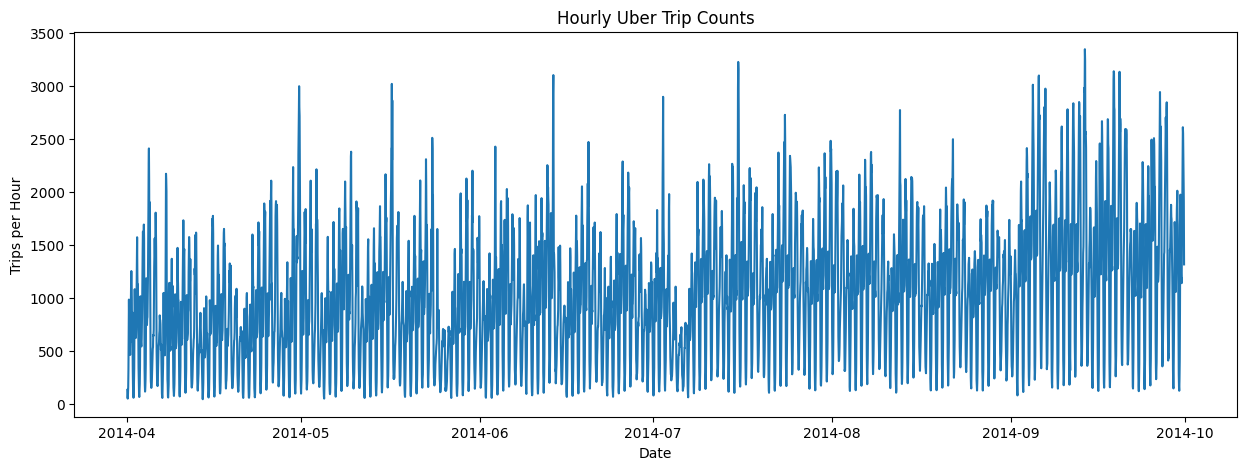

Hourly data shape: (4391,)


In [7]:
# STEP 6: Create hourly trip counts for EDA

hourly_data = uber_df["Base"].resample("H").count()

plt.figure(figsize=(15,5))
plt.plot(hourly_data)
plt.title("Hourly Uber Trip Counts")
plt.xlabel("Date")
plt.ylabel("Trips per Hour")
plt.show()

print("Hourly data shape:", hourly_data.shape)



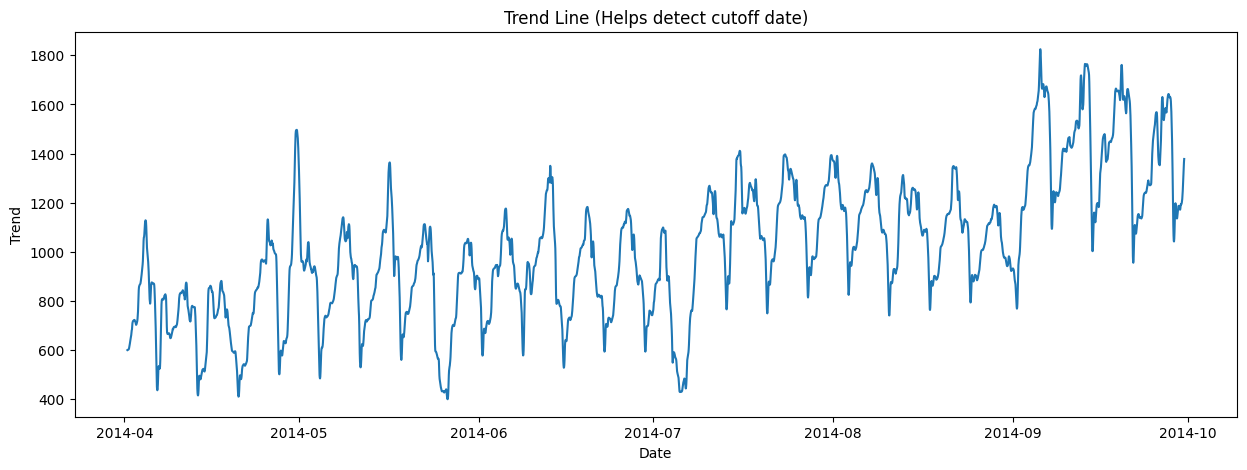

In [8]:
# STEP 7: Decompose the time series to see the trend clearly

decomp = seasonal_decompose(hourly_data, model="add", period=24)

plt.figure(figsize=(15,5))
plt.plot(decomp.trend)
plt.title("Trend Line (Helps detect cutoff date)")
plt.xlabel("Date")
plt.ylabel("Trend")
plt.show()


In [9]:
# STEP 8: Create train and test split using the cutoff date

cutoff_date = "2014-09-15 00:00:00"

train_data = hourly_data.loc[:cutoff_date]
test_data  = hourly_data.loc[cutoff_date:]

print("Train shape:", train_data.shape)
print("Test shape:", test_data.shape)

train_data.head(), test_data.head()


Train shape: (4009,)
Test shape: (383,)


(Date/Time
 2014-04-01 00:00:00    133
 2014-04-01 01:00:00     62
 2014-04-01 02:00:00     51
 2014-04-01 03:00:00     90
 2014-04-01 04:00:00    161
 Freq: h, Name: Base, dtype: int64,
 Date/Time
 2014-09-15 00:00:00    251
 2014-09-15 01:00:00    167
 2014-09-15 02:00:00    151
 2014-09-15 03:00:00    335
 2014-09-15 04:00:00    554
 Freq: h, Name: Base, dtype: int64)

In [10]:
# STEP 9: Create lag features (past 24 hours to predict next hour)

def create_lag_features(data, window=24):
    X = []
    y = []
    values = data.values

    for i in range(len(values) - window):
        X.append(values[i:i+window])
        y.append(values[i+window])

    return np.array(X), np.array(y)

# Create lag features for training data
X_train, y_train = create_lag_features(train_data, window=24)

# For testing: we need the last 24 hours of train + test data
test_input = pd.concat([train_data.tail(24), test_data])
X_test, y_test = create_lag_features(test_input, window=24)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


X_train shape: (3985, 24)
y_train shape: (3985,)
X_test shape: (383, 24)
y_test shape: (383,)


In [13]:
# STEP 11: Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_percentage_error

# time-series cross-validation
tscv = TimeSeriesSplit(n_splits=3)

rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}

rf_model = RandomForestRegressor(random_state=42)

rf_grid = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_percentage_error',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print("Best RF parameters:", rf_grid.best_params_)

# best model
rf_best = rf_grid.best_estimator_

# predictions on test set
rf_pred = rf_best.predict(X_test)

# error
rf_mape = mean_absolute_percentage_error(y_test, rf_pred)
print("Random Forest MAPE:", rf_mape)


Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best RF parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Random Forest MAPE: 0.12223901020777249


In [14]:
# STEP 12: XGBoost Regressor

import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_percentage_error

tscv = TimeSeriesSplit(n_splits=3)

# small, fast grid (still good)
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6],
    'learning_rate': [0.1, 0.3],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)

xgb_grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=xgb_param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_percentage_error',
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train, y_train)

print("Best XGBoost params:", xgb_grid.best_params_)

xgb_best = xgb_grid.best_estimator_
xgb_pred = xgb_best.predict(X_test)

xgb_mape = mean_absolute_percentage_error(y_test, xgb_pred)
print("XGBoost MAPE:", xgb_mape)


Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best XGBoost params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}
XGBoost MAPE: 0.09900294989347458


In [15]:
# STEP 13: Gradient Boosted Regression Tree (GBRT)

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_percentage_error

tscv = TimeSeriesSplit(n_splits=3)

# small, fast grid
gbr_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 4],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}

gbr_model = GradientBoostingRegressor(random_state=42)

gbr_grid = GridSearchCV(
    estimator=gbr_model,
    param_grid=gbr_param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_percentage_error',
    n_jobs=-1,
    verbose=1
)

gbr_grid.fit(X_train, y_train)

print("Best GBRT params:", gbr_grid.best_params_)

gbr_best = gbr_grid.best_estimator_
gbr_pred = gbr_best.predict(X_test)

gbr_mape = mean_absolute_percentage_error(y_test, gbr_pred)
print("GBRT MAPE:", gbr_mape)


Fitting 3 folds for each of 32 candidates, totalling 96 fits
Best GBRT params: {'learning_rate': 0.1, 'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
GBRT MAPE: 0.12343877541398152


In [16]:
# STEP 14: Ensemble model (average predictions)

# Ensure all models have their predictions ready
ensemble_pred = (xgb_pred + rf_pred + gbr_pred) / 3

# calculate MAPE
ensemble_mape = mean_absolute_percentage_error(y_test, ensemble_pred)

print("Ensemble MAPE:", ensemble_mape)


Ensemble MAPE: 0.10937931909171926


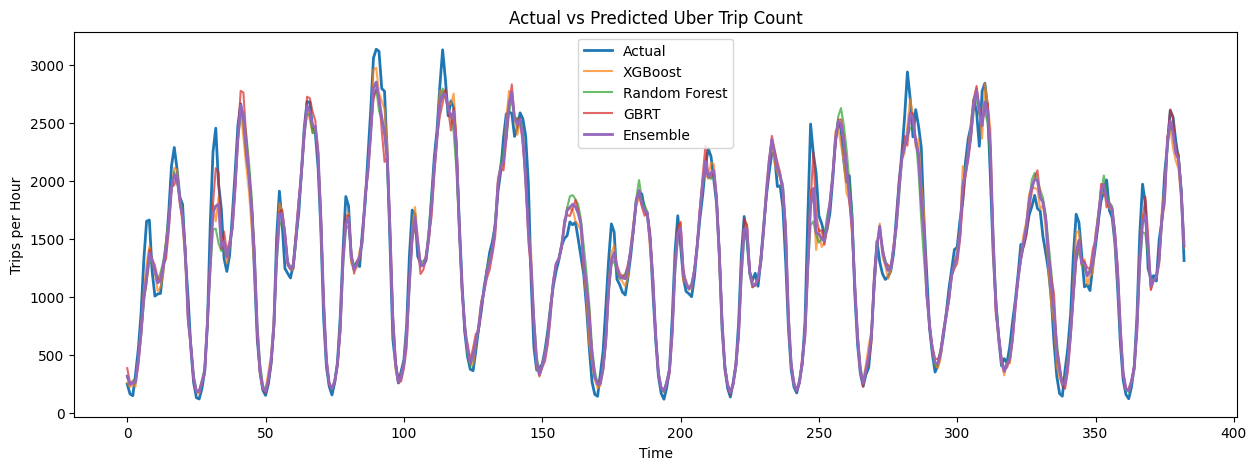

In [17]:
# STEP 15: Plot actual vs predicted values

plt.figure(figsize=(15,5))

plt.plot(y_test, label="Actual", linewidth=2)
plt.plot(xgb_pred, label="XGBoost", alpha=0.7)
plt.plot(rf_pred, label="Random Forest", alpha=0.7)
plt.plot(gbr_pred, label="GBRT", alpha=0.7)
plt.plot(ensemble_pred, label="Ensemble", linewidth=2)

plt.xlabel("Time")
plt.ylabel("Trips per Hour")
plt.title("Actual vs Predicted Uber Trip Count")
plt.legend()
plt.show()


In [18]:
# Choose 1 example index from the test set
example_index = 10   # you can change this (0,1,2,...)

# Model prediction
predicted_value = xgb_pred[example_index]

# Actual value
actual_value = y_test[example_index]

print("=== SINGLE EXAMPLE PREDICTION ===")
print("Example Index:", example_index)
print("Predicted Trips :", predicted_value)
print("Actual Trips    :", actual_value)
print("Error (diff)    :", abs(actual_value - predicted_value))
print("Percentage Error:", abs(actual_value - predicted_value) / actual_value * 100, "%")


=== SINGLE EXAMPLE PREDICTION ===
Example Index: 10
Predicted Trips : 1206.8181
Actual Trips    : 1010
Error (diff)    : 196.818115234375
Percentage Error: 19.486942102413366 %


In [19]:
import joblib

# 1) Save best XGBoost model
joblib.dump(xgb_best, "uber_xgb_model.pkl")

# 2) Save hourly data (used for last 24 hours)
hourly_for_export = hourly_data.to_frame(name="Count")
hourly_for_export.index.name = "Date"   # give a proper name to the index
hourly_for_export.to_csv("hourly_counts.csv")

print("Files saved: uber_xgb_model.pkl, hourly_counts.csv")


Files saved: uber_xgb_model.pkl, hourly_counts.csv


In [20]:
from google.colab import files

files.download("uber_xgb_model.pkl")
files.download("hourly_counts.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>